In [1]:
import importlib
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import umap
import hdbscan

import nltk
from nltk.corpus import stopwords

from bertopic import BERTopic
from joblib import Parallel, delayed
from langdetect import detect
from scipy.stats import chi2_contingency
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tqdm import tqdm

import src.fct_data
importlib.reload(src.fct_data)
from src.fct_data import raw_data_cleaning

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Extraction des données



Traitement pour les 5 années disponibles sur le `gitlab` 

In [2]:
#on récupère un df avec métadonnées + texte nettoyé des stopwords
meta_et_texts_all_info = raw_data_cleaning("data/archelect_search.zip","data/text_files")

/home/onyxia/work/NLP_3A/src/fct_data.py:16: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  metadonnees = pd.read_csv("data/archelect_search.zip", compression="zip")


Traitement de data/text_files/1993/legislatives.zip
Traitement de data/text_files/1993/presidentielle.zip
Traitement de data/text_files/1973/legislatives.zip
Traitement de data/text_files/1988/legislatives.zip
Traitement de data/text_files/1981/legislatives.zip
Traitement de data/text_files/1978/legislatives.zip
Nombre total de documents extraits : 21697


In [3]:
print(meta_et_texts_all_info.shape)
print(meta_et_texts_all_info.columns)

(21697, 46)
Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'text',
       'zip_path', 'texte_clean', 'annee'],
 

In [4]:
meta_et_texts = meta_et_texts_all_info[['date','titulaire-profession','titulaire-soutien','contexte-election','text','texte_clean','annee']]
del meta_et_texts_all_info

In [5]:
meta_et_texts['contexte-election'].value_counts()

contexte-election
législatives    21167
Name: count, dtype: int64

In [6]:
meta_et_texts = meta_et_texts[meta_et_texts['contexte-election'] == 'législatives']

In [8]:
meta_et_texts.head()


,date,titulaire-profession,titulaire-soutien,contexte-election,text,texte_clean,annee
0,1993-03-21,non mentionné,non mentionné,législatives,Département de Seine-Maritime - 12ème Circonsc...,département seinemaritime ème circonscription ...,1993.0
1,1993-03-21,non mentionné,non mentionné,législatives,ELECTIONS LEGISLATIVES DU 21 MARS 1993\nREPUBL...,elections legislatives mars republique françai...,1993.0
2,1993-03-21,attaché administration universitaire,Parti de la loi naturelle,législatives,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,sciences po fonds cevipof elections legislativ...,1993.0
3,1993-03-21,agent de maîtrise,Verts;Génération écologie,législatives,Sciences Po / fonds CEVIPOF\nENTENTE DES ECOLO...,sciences po fonds cevipof entente ecologistes ...,1993.0
4,1993-03-21,pharmacien,Génération écologie;Verts,législatives,Sciences Po / fonds CEVIPOF\nLes Verts Confédé...,sciences po fonds cevipof verts confédération ...,1993.0


## 1/ Thematic propensity by party
#### _For a specific election, calculate the distribution of themes for each political side._


We propose and compare 2 approches : (i) Non-negative matrix factorisation, (ii) Topic modeling with embeddings : Bertopic


In [25]:
# cleaning 
df = meta_et_texts.dropna(subset=['text']).copy() #remove lines without texts
df = df[df['text'].str.strip() != ''].copy() #same for lines with empty text

df = df.reset_index(drop=True)
df['annee'] = pd.to_datetime(df['date'], errors='coerce').dt.year
df = df[df["annee"].isin([1981, 1988, 1993])].copy()
print(df.shape)
df.head()

(12497, 46)


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,text,zip_path,texte_clean,annee
0,EL174_L_1988_06_001_02_2_PF_02,1988-06-12,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1988, Ain - 01, circ...",législatives,2.0,EL174,01,Ain,01 - Ain,...,non mentionné,non mentionné,non mentionné,Union pour la démocratie française;Rassembleme...,Union du rassemblement et du centre,non,LIBERTÉ - ÉGALITÉ - FRATERNITÉ\nRÉPUBLIQUE FRA...,data/text_files/1988/legislatives.zip,liberté égalité fraternité république français...,1988.0
1,EL175_L_1988_06_045_01_1_PF_01,1988-06-05,Assemblée Nationale;France;Élections législati...,"Élections législatives de 1988, Loiret - 45, c...",législatives,1.0,EL175,45,Loiret,45 - Loiret,...,non mentionné,culture;syndicat;local,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non,Sciences Po / fonds CEVIPOF\nLA FRANCE UNIE av...,data/text_files/1988/legislatives.zip,sciences po fonds cevipof france unie jeanpier...,1988.0
2,EL177_L_1988_06_094_01_1_PF_01,1988-06-05,Assemblée Nationale;France;Ve République;Élect...,"Élections législatives de 1988, Val-de-Marne -...",législatives,1.0,EL177,94,Val-de-Marne,94 - Val-de-Marne,...,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans;Ra...,Union du rassemblement et du centre,non,ÉLECTIONS LÉGISLATIVES DES 5 ET 12 JUIN 1988 1...,data/text_files/1988/legislatives.zip,élections législatives juin ere circonscriptio...,1988.0
3,EL177_L_1988_06_075_15_1_PF_04,1988-06-05,Ve République;France;Élections législatives;As...,"Élections législatives de 1988, Paris - 75, ci...",législatives,1.0,EL177,75,Paris,75 - Paris (Seine),...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,Élections Législatives\nMaurice Mercante prése...,data/text_files/1988/legislatives.zip,élections législatives maurice mercante présen...,1988.0
4,EL175_L_1988_06_033_05_1_PF_03,1988-06-05,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1988, Gironde - 33, ...",législatives,1.0,EL175,33,Gironde,33 - Gironde,...,non mentionné,politique,non mentionné,Front national,Liste entente populaire et nationale,non,Sciences Po / fonds CEVIPOF\nMaintenant la for...,data/text_files/1988/legislatives.zip,sciences po fonds cevipof maintenant force dav...,1988.0


We check the size of our texts for a better choice of model

In [4]:
lengths = df['text'].str.split().str.len()

print("Nombre de textes : ",df.shape[0])
print("Moyenne :", lengths.mean())
print("Médiane :", lengths.median())
print("Max :", lengths.max())
print("Min :", lengths.min())

Nombre de textes :  12497
Moyenne : 634.708089941586
Médiane : 563.0
Max : 3232
Min : 27


#### (i) Non-negative matrix factorisation

In [6]:
# lemmatisation : 6 min pour 1 election
# python -m spacy download fr_core_news_sm A INSTALLER A LA PREMIERE UTILISATION

start_load = time.time()

nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

print(f"Modèle chargé en {time.time() - start_load:.2f}s\n")

def lemmatize_batch(texts, batch_size=1000):
    total_docs = len(texts)
    print(f"Début de la lemmatisation de {total_docs} documents\n")

    start_total = time.time()
    results = []

    processed = 0
    batch_id = 0

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=2):
        lemmas = " ".join(
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and token.is_alpha and len(token) > 2
        )
        results.append(lemmas)

        processed += 1

        # print tous les 1000 docs
        if processed % 1000 == 0:
            elapsed = time.time() - start_total
            speed = processed / elapsed
            print(f"{processed}/{total_docs} docs | {speed:.1f} docs/sec | {elapsed/60:.2f} min")

    total_time = time.time() - start_total

    print("\nLemmatisation terminée")
    print(f"Documents traités : {total_docs}")
    print(f"Temps total : {total_time/60:.2f} min")

    return results


# Application
df['lemmatized_text'] = lemmatize_batch(df['text'].tolist())

Modèle chargé en 11.33s

Début de la lemmatisation de 12497 documents

1000/12497 docs | 7.7 docs/sec | 2.16 min
2000/12497 docs | 14.1 docs/sec | 2.37 min
3000/12497 docs | 12.2 docs/sec | 4.11 min
4000/12497 docs | 13.5 docs/sec | 4.93 min
5000/12497 docs | 13.1 docs/sec | 6.38 min
6000/12497 docs | 13.4 docs/sec | 7.48 min
7000/12497 docs | 13.9 docs/sec | 8.39 min
8000/12497 docs | 14.0 docs/sec | 9.54 min
9000/12497 docs | 14.3 docs/sec | 10.46 min
10000/12497 docs | 14.2 docs/sec | 11.76 min
11000/12497 docs | 14.2 docs/sec | 12.91 min
12000/12497 docs | 14.7 docs/sec | 13.63 min

Lemmatisation terminée
Documents traités : 12497
Temps total : 13.69 min


On sauvegarde les données intermédiaires pour gagner du temps dans l'exécution et pouvoir les récupérer directement depuis data/inter

In [ ]:
#df.to_parquet("data/inter/df_lemmatized.parquet", engine="pyarrow", index=False, compression="snappy")

In [5]:
df = pd.read_parquet("data/inter/df_lemmatized.parquet")

In [6]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
# NMF global (tous élections confondues)
N_TOPICS = 6

#stopwords 
custom_stopwords = [
    # Mots génériques non thématiques
    "monsieur", "madame", "politique", "france", "français", "françaises",
    "faire", "être", "avoir", "falloir", "pouvoir", "devoir",
    "ici", "nom", "vie", "année","bulletin","pays","électeur","liste",
    "député","gauche","droite","majorité","parti","juin","gouvernement",
    "maire","président","marseille",
    
    # Étiquettes de partis / personnes
    "rpr", "udf", "communiste", "socialiste", "ecologiste", "écologiste",
    "lepen", "mitterrand", "ruffi","françois","mitterrand",
    "front", "national", 
] + stopwords.words('german')+ stopwords.words('french')


In [9]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.4,   #  on supprime les mots présents dans plus de la moitié des textes
    min_df=15,     # on supprime ceux dans moins de 15 textes
    max_features = 20000, #on limite la taille des mots à enregistrer
    stop_words=custom_stopwords,  
)
print('ok def tfidf')
tfidf = tfidf_vectorizer.fit_transform(df['lemmatized_text'])
print('tf-idf fini')
# Non-negative matrix factorisation
nmf = NMF(n_components=N_TOPICS, random_state=2026)
W = nmf.fit_transform(tfidf)
H = nmf.components_
print(' NMF fini')

# Affichage des mots par topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in np.argsort(-topic)[:20]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}\n")

# Normalisation
W_normalized = W / W.sum(axis=1, keepdims=True)
df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['topic_score']    = np.max(W_normalized, axis=1)

# Ajout des poids au dataframe
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

ok def tfidf
tf-idf fini
 NMF fini
Topic 0: changement, général, tour, liberté, progrès, ensemble, formation, action, dimanche, michel, mai, jeune, service, non, besoin, europe, savoir, femme, développement, moyen

Topic 1: nature, animaux, existence, rassemblement, activité, corrida, vivisection, accés, minimun, complét, feuille, spirituel, découper, véto, gratuitement, panorama, abattoir, prénom, massacre, postal

Topic 2: vote, suppression, votez, conviction, populaire, payent, antisocialiste, fiscalist, octroi, absent, effectivement, quant, joindre, assassin, hégémonie, apprêter, presque, collègue, contribuable, préconiser

Topic 3: immigration, rétablir, immigré, impôt, carte, sauver, supprimer, million, main, nationalité, voix, séjour, corruption, rien, traité, proteger, retraite, renouvelable, vérité, code

Topic 4: patron, travailleur, payer, patronat, maintenir, sacrifice, jeter, bourgeoisie, vendre, bénéfice, banque, ouvrière, salaire, employé, ruiner, sacrifier, dire, rue, r

In [10]:
# labels input
topic_label = {
    0: "appel à l'alternance",
    1: "protection de l'environnement et des animaux",
    2: 'fiscalité',
    3: 'immigration',
    4: 'lutte sociale', 
    5: 'écologie et générations futures'
}

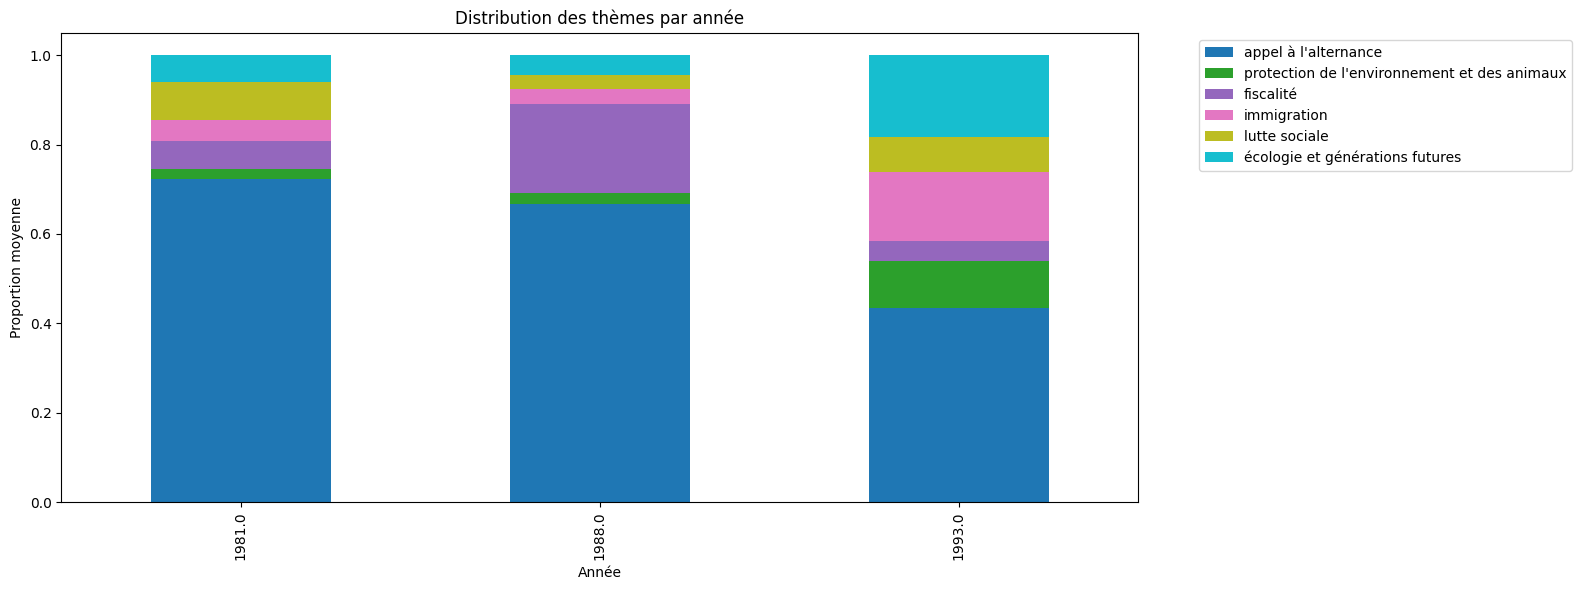

In [11]:
# topics / doc 


W_normalized = W / W.sum(axis=1, keepdims=True)

df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['dominant_label'] = df['dominant_topic'].map(topic_label)
df['topic_score']    = np.max(W_normalized, axis=1)

# topic distrib / year 
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]

# ajout colonnes
df = df.drop(columns=[col for col in df.columns if col.startswith('topic_')], errors='ignore')
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

topic_by_year = df.groupby('annee')[topic_cols].mean()

topic_by_year.rename(
    columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
).plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année")
plt.ylabel("Proportion moyenne")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


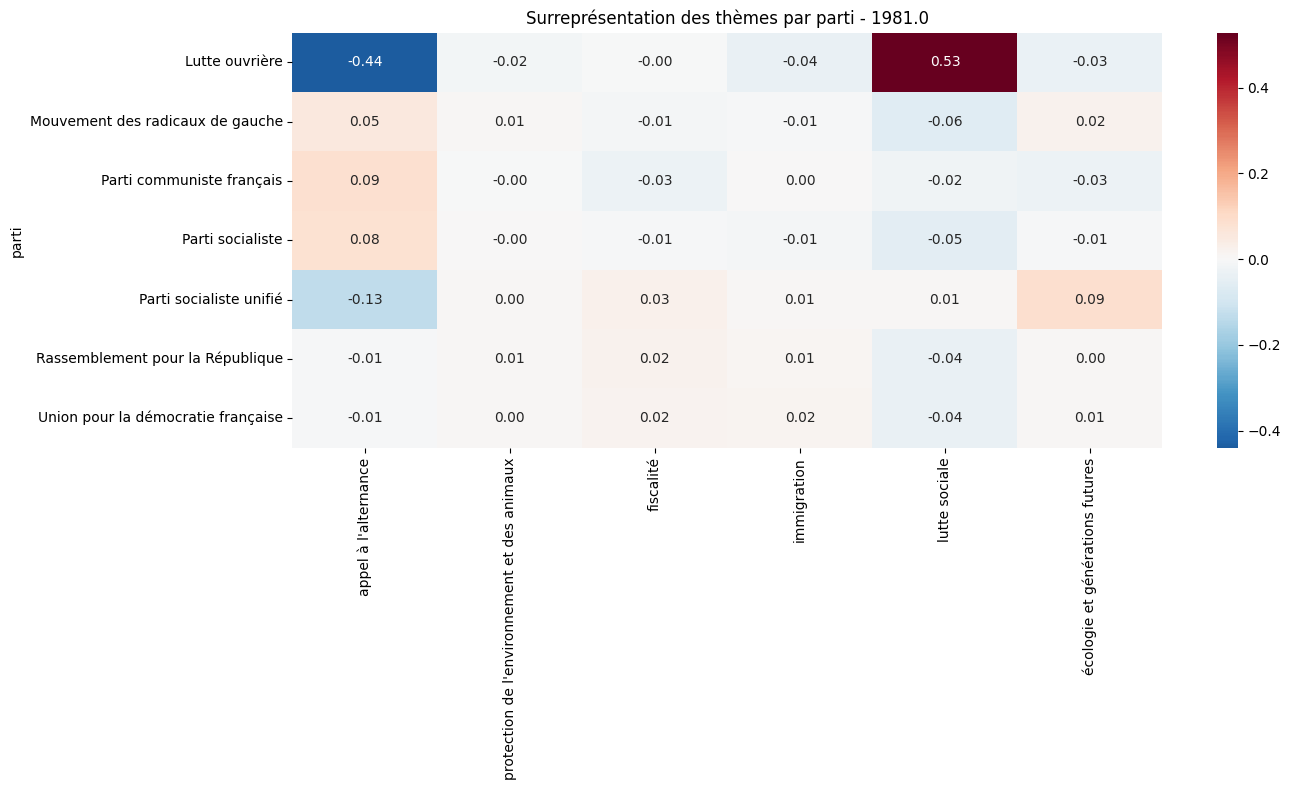

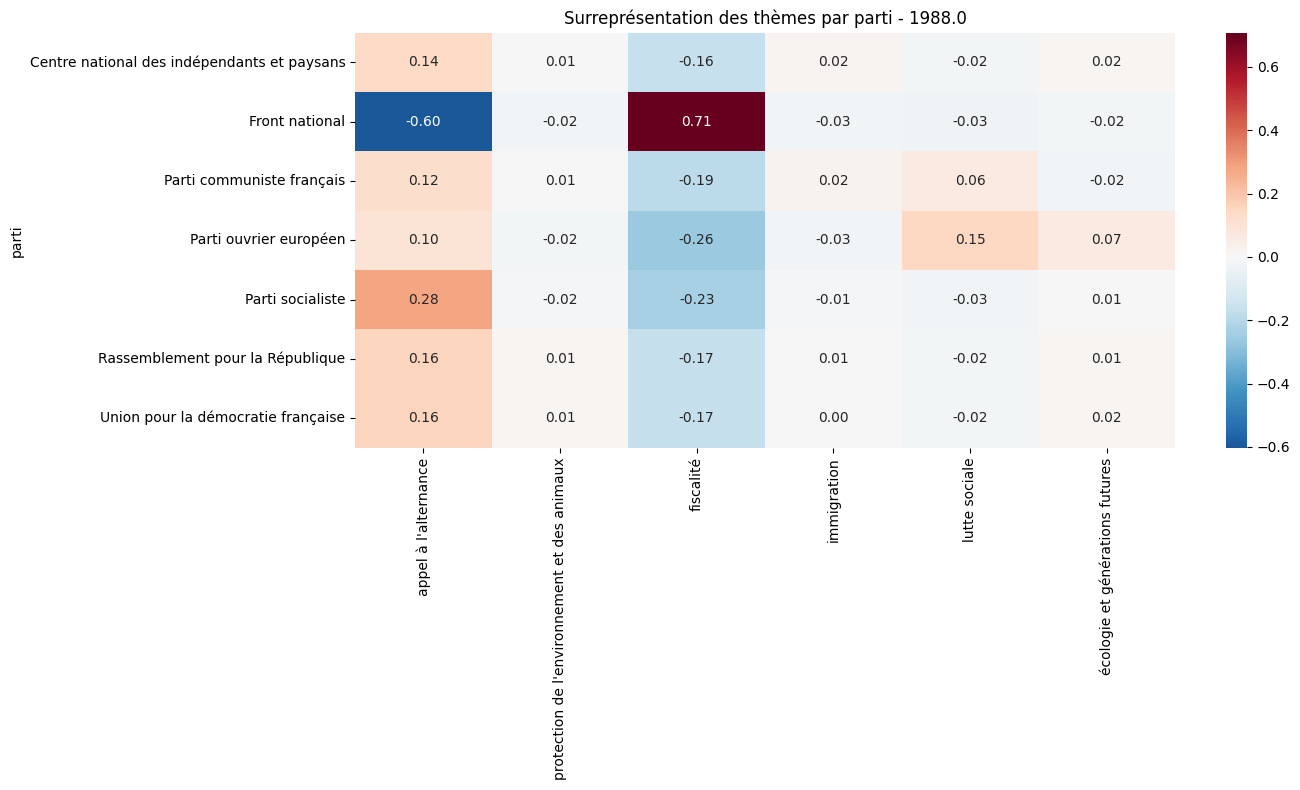

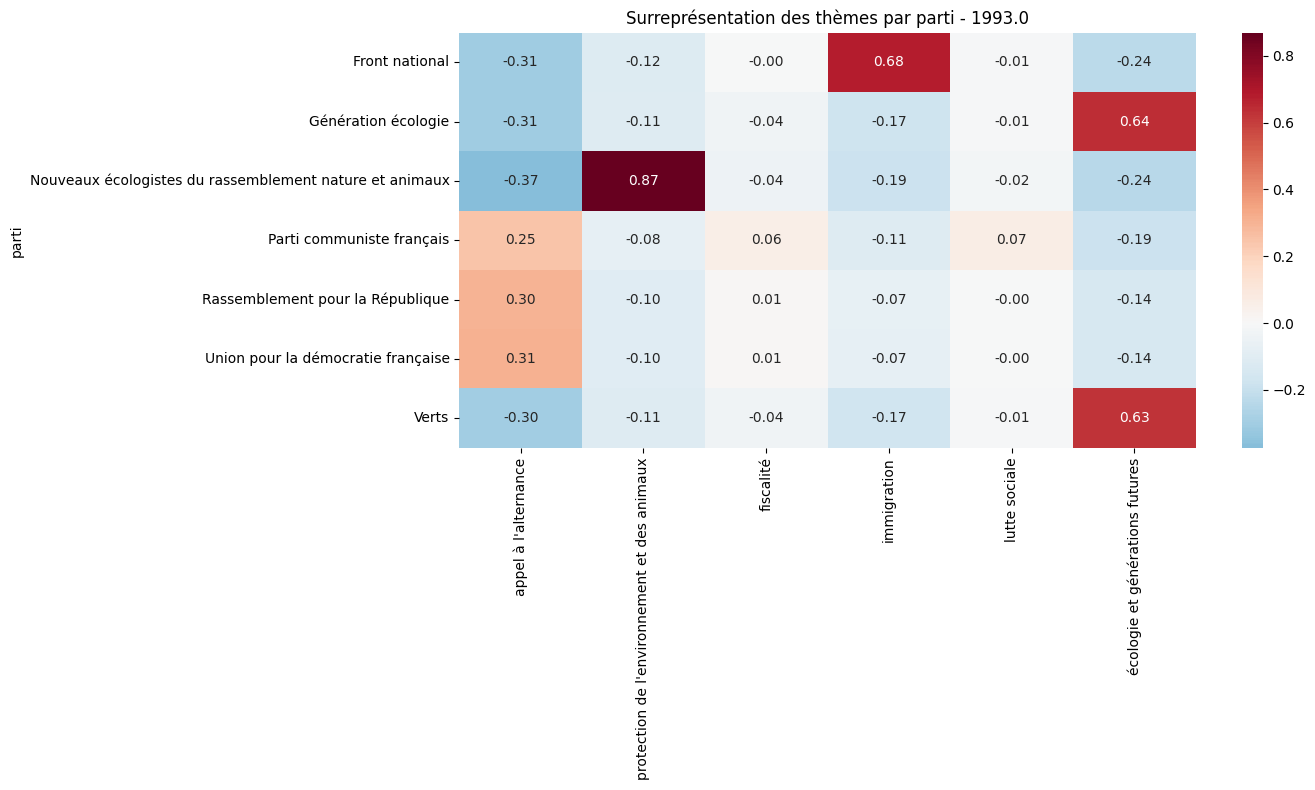

In [12]:
# créer un DataFrame explosé pour les partis
df_exploded = df.copy()
df_exploded['parti'] = df_exploded['titulaire-soutien'].str.split(';')
df_exploded = df_exploded.explode('parti')
df_exploded['parti'] = df_exploded['parti'].str.strip()
df_exploded = df_exploded[df_exploded['parti'].notna()]
df_exploded = df_exploded[df_exploded['parti'] != "non mentionné"]
df_exploded = df_exploded[df_exploded['parti'] != ""]

# boucle par année
for year, df_year in df_exploded.groupby('annee'):

    # compter les partis pour cette année et garder top nb_partis
    nb_partis = 7
    parti_counter = Counter(df_year['parti'])
    top_partis = [p for p, _ in parti_counter.most_common(nb_partis)]
    df_top = df_year[df_year['parti'].isin(top_partis)]

    # calcul surreprésentation
    global_mean = df_top[topic_cols].mean()
    topic_by_parti = df_top.groupby('parti')[topic_cols].mean()
    surreprésentation = topic_by_parti - global_mean

    # heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        surreprésentation.rename(
            columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
        ),
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f'
    )
    plt.title(f"Surreprésentation des thèmes par parti - {year}")
    plt.tight_layout()
    plt.show()

#### (ii) Topic modeling with embeddings : Bertopic

Il y avait ce code, qui me parait redondant avec ce qui a été fait plus haut
@Matéo enlève le si t'es ok

#cleaning
mask = df['text'].notna() & (df['text'].str.strip() != '') #on enlève les lignes où le texte est inexistant ou vide
df   = df[mask].reset_index(drop=True)



In [4]:
docs = df['text'].tolist()
# embeddings //
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

num_cores  = -1
chunk_size = 300
batch_size = 32
chunks     = [docs[i:i+chunk_size] for i in range(0, len(docs), chunk_size)]
num_chunks = len(chunks)
print(f"Nombre total de chunks : {num_chunks}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 499.30it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Nombre total de chunks : 42


In [ ]:

def encode_chunk(chunk, chunk_idx):
    start      = time.time()
    embeddings = embedding_model.encode(chunk, batch_size=batch_size, convert_to_numpy=True)
    elapsed    = time.time() - start
    print(f"Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed

start_total    = time.time()
results        = Parallel(n_jobs=num_cores, prefer="threads")(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)
embeddings     = np.vstack([res[0] for res in results])
total_time     = time.time() - start_total

print(f"\n Embeddings générés pour {len(docs)} textes")
print(f"Shape : {embeddings.shape}")
print(f"Temps total : {total_time/60:.2f} minutes")

In [ ]:
#nltk.download('stopwords')
STOPWORDS = stopwords.words('french')+stopwords.words('german')

word_counter = Counter()
for doc in docs:
    word_counter.update(doc.lower().split())

# top 30 mots les plus fréquents hors stopwords
top = [
    word for word, _ in word_counter.most_common(200)
    if word not in STOPWORDS
][:60] #jusqu'à 65 les mots sont peu informatifs

print("Mots les plus fréquents à retirer :", top)

STOPWORDS = list(set(STOPWORDS + top))

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Mots les plus fréquents à retirer : ['-', ':', '·', 'a', 'plus', '/', 'fonds', 'po', "c'est", 'cevipof', 'politique', 'tous', 'france', 'sciences', 'faire', '☐', 'candidat', 'circonscription', 'comme', '!', ';', '...', 'faut', 'majorité', 'français', 'contre', 'cette', 'tout', 'parti', 'sans', 'leurs', 'juin', 'votez', 'toutes', "d'une", 'conseiller', 'gauche', 'si', 'droite', 'député', 'être', 'candidats', 'vie', 'ceux', "d'un", 'ans', 'législatives', 'suppléant', 'depuis', '21', 'nouvelle', 'mars', 'maire', 'élections', 'fait', '5', 'vote', 'voter', '?', 'président']


In [57]:
# UMAP et HDBScan // 
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    n_components=5,
    random_state=42,
    n_jobs=-1
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=50,
    cluster_selection_epsilon=0.01,
    core_dist_n_jobs=-1,
    prediction_data=True  
)

# Bertopic
vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS,
    min_df=3
)

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='french',
    nr_topics=10,
    calculate_probabilities=True,
)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings) #  BERTopic l'embeddings car déjà fait

# ajout au df
print(topic_model.get_topic_info())

df['BERTopic_dominant'] = topics
df['BERTopic_score']    = probs.max(axis=1)

   Topic  Count                                        Name  \
0     -1    351   -1_travailleurs_patrons_emplois_maintenir   
1      0  10702               0_pays_nationale_jean_sociale   
2      1    389            1_national_front_nationale_force   
3      2    362     2_nature_animaux_nouveaux_rassemblement   
4      3    173          3_patrons_maintenir_payer_patronat   
5      4    154  4_mitterrand_ouvrière_travailleurs_députés   
6      5    131              5_national_front_nationale_udf   
7      6     90          6_accepter_pouvons_illusion_europe   
8      7     86                 7_travailleurs_unité_lcr_ps   
9      8     59                    8_12_refus_maintien_mise   

                                      Representation  \
0  [travailleurs, patrons, emplois, maintenir, en...   
1  [pays, nationale, jean, sociale, union, vu, em...   
2  [national, front, nationale, force, udf, rpr, ...   
3  [nature, animaux, nouveaux, rassemblement, exi...   
4  [patrons, maintenir, pa

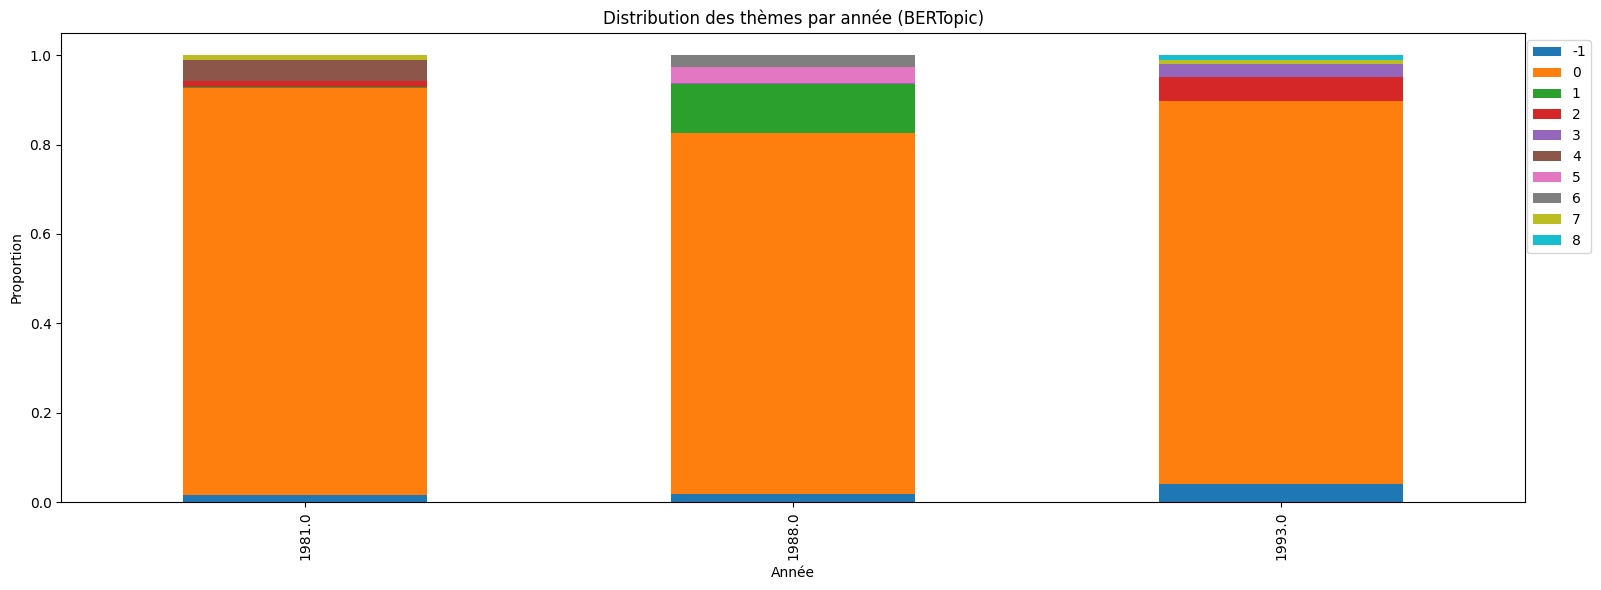

In [58]:
#distrib topic par année
topic_info = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()

topic_by_year = df.groupby(['annee', 'BERTopic_dominant']).size().unstack(fill_value=0)
topic_by_year = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)  # normalisation

topic_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année (BERTopic)")
plt.ylabel("Proportion")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### (ii bis) Bertopic par Caroline (très similaire à ce que j'ai fait au dessus) 
@caroline : mon BERT fonctionne très mal, cf. graphique d'au dessus par rapport à celui de NMF qui n'a pas un cluster qui écrase tout le monde.
il faudrait voir si c'est pareil pour ton code 

In [9]:
#  Chargement de stopwords français
try:
    nlp = spacy.load("fr_core_news_sm")
except:
    !python -m spacy download fr_core_news_sm
    nlp = spacy.load("fr_core_news_sm")

stopwords_fr = nlp.Defaults.stop_words

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 11.6 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


In [10]:
all_text = " ".join(meta_et_texts['texte_clean'].astype(str)).lower()

In [11]:
all_text[0:10000]

'département seinemaritime ème circonscription scrutin mars alain vern député maire saintsaëns ans suppléant docteur christian plailly maire gaillefontaine ans chère madame chère mademoiselle cher monsieur voici ans élu député depuis consacré tout temps toute énergie être digne confiance période électorale trop souvent celle divisions belles promesses jugez actes faits tout réussi bien sûr travaillé rassembler unir intérêt circonscription habitants pays circonscription agi construction logements gournay feuillie buchy saintsaëns neuville ferrières neufchâtel londinières blangy torcy grand bellencombre centaine an lieu dizaine an avant désenclavement routier rn rouen dieppe autoroute a ouverte décembre dernier jusqu neufchâtel rn aménagée formation meilleure qualité adaptation formations bacs professionnels liaison entreprises ouvertures bts maternelles maintien lignes sncf grâce action elus usagers syndicats blangy aumale paris tréport ferrières gournay forges serqueux parisgisorsserqu

In [12]:
# Identification des mots les plus fréquents
# On concatène tous les textes
all_text = " ".join(meta_et_texts['texte_clean'].astype(str)).lower()
tokens = all_text.split()
# compter les mots
word_counts = Counter(tokens)
# choisir les 20 mots les plus fréquents à exclure
top_20_words = [w for w, c in word_counts.most_common(20)]
print("Mots les plus fréquents à retirer :", top_20_words)

Mots les plus fréquents à retirer : ['a', 'plus', 'fonds', 'tous', 'po', 'politique', 'ans', 'gauche', 'circonscription', 'cevipof', 'france', 'candidat', 'parti', 'sciences', 'travailleurs', 'français', 'comme', 'mars', 'faire', 'tout']


In [13]:
top_words_set = set(top_20_words)

def remove_top_words(text):
    return " ".join([
        w for w in text.split()
        if w not in top_words_set
    ])

meta_et_texts['texte_clean'] = meta_et_texts['texte_clean'].apply(remove_top_words)

In [14]:
meta_et_texts_metier = meta_et_texts[meta_et_texts['titulaire-profession'] != 'non mentionné']
print(meta_et_texts.shape)
print(meta_et_texts_metier.shape)

(21167, 7)
(11702, 7)


In [ ]:
#meta_et_texts=meta_et_texts[meta_et_texts["annee"]=="1981"].copy()

In [15]:
#on vérifie juste qu'il n'y a pas de texte vide, ca ferait planter l'encodeur
nan_count = meta_et_texts_metier['texte_clean'].isna().sum()
print(f"Nombre de valeurs NaN : {nan_count}")

Nombre de valeurs NaN : 0


In [16]:
#on passe ça en liste pure python
texts = meta_et_texts_metier['texte_clean'].tolist()

In [17]:
len(texts)

11702

In [18]:
longueurs_mots = [len(t.split()) for t in texts]
print(longueurs_mots)
import statistics

print("Moyenne :", statistics.mean(longueurs_mots))
print("Min :", min(longueurs_mots))
print("Max :", max(longueurs_mots))
print("Écart-type :", statistics.stdev(longueurs_mots))

[430, 316, 285, 447, 549, 360, 267, 250, 399, 512, 138, 250, 524, 58, 394, 442, 272, 201, 459, 321, 312, 98, 428, 392, 431, 457, 544, 109, 294, 429, 146, 456, 284, 276, 441, 161, 161, 358, 497, 562, 280, 225, 483, 148, 367, 565, 305, 315, 219, 390, 194, 340, 240, 412, 345, 228, 451, 675, 279, 528, 300, 168, 262, 275, 312, 207, 246, 230, 203, 264, 159, 218, 353, 445, 334, 209, 345, 459, 157, 340, 118, 257, 455, 235, 420, 426, 168, 826, 304, 560, 271, 351, 383, 263, 209, 270, 503, 397, 207, 291, 363, 220, 302, 255, 456, 216, 436, 375, 450, 187, 155, 365, 487, 432, 129, 308, 505, 532, 330, 422, 585, 276, 305, 332, 387, 243, 596, 244, 430, 139, 431, 449, 426, 135, 579, 424, 396, 196, 159, 292, 344, 484, 441, 138, 266, 330, 315, 426, 349, 408, 210, 427, 355, 450, 381, 423, 173, 813, 429, 328, 289, 216, 432, 274, 339, 451, 378, 139, 213, 275, 438, 408, 427, 439, 246, 559, 479, 524, 560, 476, 338, 157, 233, 1046, 245, 158, 138, 289, 192, 401, 381, 394, 419, 596, 292, 101, 579, 308, 427, 451, 

In [19]:
# On charge un modèle
import torch
torch.set_num_threads(1)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device='cpu')
#model = SentenceTransformer('CATIE-AQ/camembert-base-embedding', device='cpu')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 812.12it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
# Define parameters
#chunk_size = 1000       # Chunks size to parallelize
#batch_size = 2048       # batch_size inside model
#num_cores = 8       #  Number of CPU threads to use for joblib

chunk_size = 250       # textes par chunk
batch_size = 64      # batch interne
num_cores  = 16         # processus joblib


Embedding : we transform texts into vectors of numbers ; to do so, we create chunks of texts that are transformed into number
Around 3'30

In [23]:
# put the texts together in chunks
chunks = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]
num_chunks = len(chunks)

print(f"Nombre total de chunks : {num_chunks}")

# Function to encode chunk
def encode_chunk(chunk, chunk_idx):
    start = time.time()
    embeddings = model.encode(chunk, batch_size=batch_size,show_progress_bar=True, convert_to_numpy=True)
    end = time.time()
    elapsed = end - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed


# Parallel encoding with timer
start_total = time.time()

results = Parallel(n_jobs=num_cores)(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)

# Séparer embeddings et temps par chunk
embeddings_list = [res[0] for res in results]
chunk_times = [res[1] for res in results]

# We put back together all the embeddings
embeddings = np.vstack(embeddings_list)
total_time = time.time() - start_total


# Some statistics on the embeddings
print(f"\nEmbeddings générés pour {len(texts)} textes")
print(f"Shape des embeddings : {embeddings.shape}")
print(f"Temps total écoulé : {total_time/60:.2f} minutes")
print(f"Temps moyen par chunk : {np.mean(chunk_times):.2f} secondes")
print(f"Temps estimé si encore {num_chunks} chunks : {np.mean(chunk_times)*(num_chunks-1)/60:.2f} minutes")

Nombre total de chunks : 47


Batches:  75%|███████▌  | 3/4 [00:11<00:03,  3.88s/it]

✅ Chunk 1/47 traité en 16.73s


Batches: 100%|██████████| 4/4 [00:15<00:00,  3.76s/it]


✅ Chunk 2/47 traité en 15.08s


...

Batches: 100%|██████████| 4/4 [00:13<00:00,  3.25s/it]


✅ Chunk 45/47 traité en 13.05s


Batches: 100%|██████████| 4/4 [00:10<00:00,  2.66s/it]


✅ Chunk 47/47 traité en 10.68s
✅ Chunk 46/47 traité en 15.97s

Embeddings générés pour 11702 textes
Shape des embeddings : (11702, 384)
Temps total écoulé : 3.27 minutes
Temps moyen par chunk : 14.21 secondes
Temps estimé si encore 47 chunks : 10.90 minutes


Batches: 100%|██████████| 4/4 [00:15<00:00,  3.98s/it]


#### Classification par thème (suite ii bis BERT caroline)

Ci-dessous, on transforme notre embedding en vecteurs de bcp plus petite dimension (environ 20 sec avec ces paramètre d'UMAP)

In [32]:
umap_embeddings = umap.UMAP(
    n_neighbors=15, min_dist=0.3, n_components=5, random_state=42, verbose = True
).fit_transform(embeddings)
print(f"UMAP embeddings shape: {umap_embeddings.shape}")

UMAP(min_dist=0.3, n_components=5, n_jobs=1, random_state=42, verbose=True)
Sat Mar 28 16:17:56 2026 Construct fuzzy simplicial set
Sat Mar 28 16:17:56 2026 Finding Nearest Neighbors
Sat Mar 28 16:17:56 2026 Building RP forest with 10 trees
Sat Mar 28 16:17:56 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Sat Mar 28 16:17:58 2026 Finished Nearest Neighbor Search
Sat Mar 28 16:17:58 2026 Construct embedding


Epochs completed:   3%| ▎          6/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         23/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  92%| █████████▎ 185/200 [00:11]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:12]


Sat Mar 28 16:18:11 2026 Finished embedding
UMAP embeddings shape: (11702, 5)


DBScan ci-dessous va créer des clusters thématiques

In [34]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100,
                            min_samples=10,  # moins strict sur la densité
                            cluster_selection_method='leaf')
#on ajoute à notre dataframe le thème abordé par le candidat
meta_et_texts_metier['theme_cluster'] = clusterer.fit_predict(umap_embeddings)
print(f"Clusters trouvés : {meta_et_texts_metier['theme_cluster'].nunique()} (le -1 correspond aux outliers)")


Clusters trouvés : 14 (le -1 correspond aux outliers)


On essaie de labelliser les thèmes automatiquement

In [36]:
#on reliste tous les mots éliminés
all_stopwords = stopwords_fr.union(top_20_words)

# Function to get the "op words" per cluster
def get_top_words_filtered(texts, n=10):
    # put together all words in the cluster
    all_words = " ".join(texts).lower().split()
    # Remove all the words from the stowords list
    all_words = [w for w in all_words if w not in all_stopwords]
    # counting
    return Counter(all_words).most_common(n)

# Go through all clusters
for cluster_id in sorted(meta_et_texts_metier['theme_cluster'].unique()):
    if cluster_id == -1:  # ignore outliers if needed
        continue
    texts = meta_et_texts_metier[meta_et_texts_metier['theme_cluster'] == cluster_id]['texte_clean']  # utiliser la colonne filtrée
    top_words = get_top_words_filtered(texts,15)
    print(f"Cluster {cluster_id}: {top_words}")

Cluster 0: [('suppléant', 2279), ('lutte', 1403), ('progrès', 1019), ('candidats', 898), ('vote', 888), ('etat', 768), ('voter', 762), ('avertissement', 756), ('ouvrier', 642), ('révolutionnaires', 640), ('tour', 638), ('ouvriere', 630), ('ouvrière', 525), ('e', 524), ('gouvernement', 516)]
Cluster 1: [('national', 1957), ('front', 1614), ('vote', 1289), ('nationale', 1241), ('avenir', 919), ('rpr', 917), ('udf', 916), ('force', 915), ('votez', 645), ('populaire', 617), ('contre', 614), ('suppression', 614), ('convictions', 614), ('députés', 613), ('ici', 613)]
Cluster 2: [('voter', 2114), ('mitterrand', 1844), ('petits', 1483), ('contre', 1482), ('marchais', 1449), ('droite', 1271), ('lutte', 1267), ('femmes', 1065), ('travailleuses', 1056), ('gouvernement', 894), ('candidats', 855), ('hommes', 850), ('politiques', 822), ('commerçants', 813), ('ouvriere', 714)]
Cluster 3: [('voter', 1339), ('mitterrand', 1168), ('contre', 938), ('petits', 937), ('marchais', 888), ('droite', 804), ('fe

## 2/ Croisement avec les professions des candidats

@caroline pour le moment c'est ton code basé sur ton analyse des thèmes (ie. l'analyse de ii bis)
à voir quelle analyse thématique on garde et donc à adapter en conséquence

Analyse exploratoire

In [37]:
print(meta_et_texts['titulaire-profession'].nunique())
print(meta_et_texts['titulaire-profession'].value_counts())

print(meta_et_texts_metier['titulaire-profession'].nunique())
print(meta_et_texts_metier['titulaire-profession'].value_counts())

3397
titulaire-profession
non mentionné                                             9465
professeur                                                 480
avocat                                                     368
chef d'entreprise                                          234
ingénieur                                                  232
                                                          ... 
ouvrier affûteur                                             1
notaire rural;professeur droit rural Ecole de notariat       1
chirurgien Centre hospitalier                                1
travailleuse foyer                                           1
technicien gestion industrielle                              1
Name: count, Length: 3397, dtype: int64
3396
titulaire-profession
professeur                                                480
avocat                                                    368
chef d'entreprise                                         234
ingénieur                    

On a plus de 3000 professions différentes, pas vraiment d'organisation ou de nomenclature déjà déterminée ; on va donc également utiliser de l'embedding et du clustering pour attribuer aux candidats une catégorie plus vaste de métier

In [38]:
#cleaning en préambule
professions = meta_et_texts_metier['titulaire-profession'].dropna()
professions_clean = (
    professions
    .str.lower()
    .str.strip()
    #la ligne ci-dessous permet de supprimer le point-virgule séparant les différents métiers déclarés par une même personne
    .str.replace(";", " ", regex=False) 

)
unique_professions = professions_clean.unique()

def clean_prof(x):
    x = re.sub(r"[^\w\s-]", "", x)
    return x

unique_professions = [clean_prof(p) for p in unique_professions]
len(unique_professions)

3383

In [39]:
#Job Embedding (2min)
model_professions = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings_professions = model_professions.encode(unique_professions,
                                                batch_size=256,
                                                show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 888.71it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [02:18<00:00,  9.92s/it]


In [44]:
from sklearn.cluster import KMeans

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings_professions)
prof_cluster_df = pd.DataFrame({
    "profession": unique_professions,
    "cluster": clusters
})

In [53]:
cluster_map = dict(zip(prof_cluster_df.profession, prof_cluster_df.cluster))

meta_et_texts_metier["profession_clean"] = (
    meta_et_texts_metier["titulaire-profession"]
    .str.lower()
    .str.strip()
)

meta_et_texts_metier["profession_cluster"] = (
    meta_et_texts_metier["profession_clean"]
    .map(cluster_map)
)

In [54]:
#Analyse des clusters
for i in range(n_clusters):
    print("\nCluster", i)
    print(prof_cluster_df[prof_cluster_df.cluster == i].profession.tolist())


Cluster 0
['administrateur civil', 'secrétaire général entreprise', 'greffier en chef', 'cadre fonction publique territoriale', 'directeur maison de retraite', 'cadre fonction publique', 'secrétaire attachée', 'instituteur secrétaire mairie', 'président directeur général entreprise', 'administrateur centre dinformation du rock', 'directeur  développement', 'assistante parlementaire', 'secrétaire direction', 'directeur cabinet préfet', 'gérant réseau télématique du centre', 'secrétaire général', 'conseiller gestion et environnement', 'directeur bureau détudes environnement', 'ambassadeur', 'conseil entreprise directeur cabinet', 'ministère de lintérieur', 'chargée de mission sénat', 'directeur centre de tourisme', 'directeur conseiller institut de sondages', 'secrétaire mairie', 'secrétaire comptable', 'inspecteur finances directeur administration centrale', 'fonctionnaire territorial', 'directeur établissement public', 'directeur tourisme ville', 'directeur groupe communication intern

In [55]:
cluster_labels = {
0: "fct_publique_admin",
1: "commercant_cadre_commercial",
2: "medical",
3: "legal",
4: "chef_prive",
5: "education_nationale",
6: "armee_aeronautique",
7: "employes_divers",
8: "technicien",
9: "ingenieur",
10: "journaliste",
11: "agriculture"
}

On ajoute les catégories des métiers au dataframe de base

In [56]:
meta_et_texts_metier["profession_category"] = (
    meta_et_texts_metier["profession_cluster"]
    .map(cluster_labels)
)

### Analyse conjointe des sujets des professions de foi et des métiers

In [57]:
pd.crosstab(
    meta_et_texts_metier["profession_category"],
    meta_et_texts_metier["theme_cluster"],
    normalize="index"
)

theme_cluster,-1,0,1,2,3,4,5,6,7,8,9,10,11,12
profession_category,,,,,,,,,,,,,,
agriculture,0.661491,0.000000,0.055901,0.000000,0.000000,0.071429,0.012422,0.031056,0.006211,0.062112,0.006211,0.055901,0.012422,0.024845
armee_aeronautique,0.568182,0.005682,0.119318,0.005682,0.000000,0.034091,0.000000,0.017045,0.005682,0.056818,0.011364,0.119318,0.000000,0.056818
chef_prive,0.655324,0.014270,0.050494,0.004391,0.001098,0.045005,0.013172,0.010977,0.015368,0.076839,0.010977,0.071350,0.007684,0.023052
commercant_cadre_commercial,0.605313,0.022138,0.021505,0.022138,0.039216,0.064516,0.008855,0.028463,0.007590,0.080961,0.027830,0.033523,0.008223,0.029728
education_nationale,0.688517,0.000493,0.011828,0.009857,0.013800,0.072942,0.006900,0.030064,0.018728,0.056678,0.024150,0.018236,0.012814,0.034993
employes_divers,0.612210,0.035254,0.019776,0.058469,0.009458,0.039553,0.014617,0.019776,0.015477,0.079966,0.026655,0.029235,0.010318,0.029235
fct_publique_admin,0.688253,0.003012,0.030120,0.000000,0.004518,0.055723,0.006024,0.013554,0.019578,0.084337,0.012048,0.034639,0.009036,0.039157
ingenieur,0.609489,0.009124,0.036496,0.018248,0.001825,0.096715,0.009124,0.025547,0.014599,0.087591,0.014599,0.043796,0.009124,0.023723
journaliste,0.653226,0.004032,0.048387,0.000000,0.004032,0.060484,0.032258,0.020161,0.016129,0.056452,0.024194,0.032258,0.008065,0.040323


11 est une catégorie qui a l'air très "fourre-tout", on a clairement pas un résultat fou

##### Visualisation

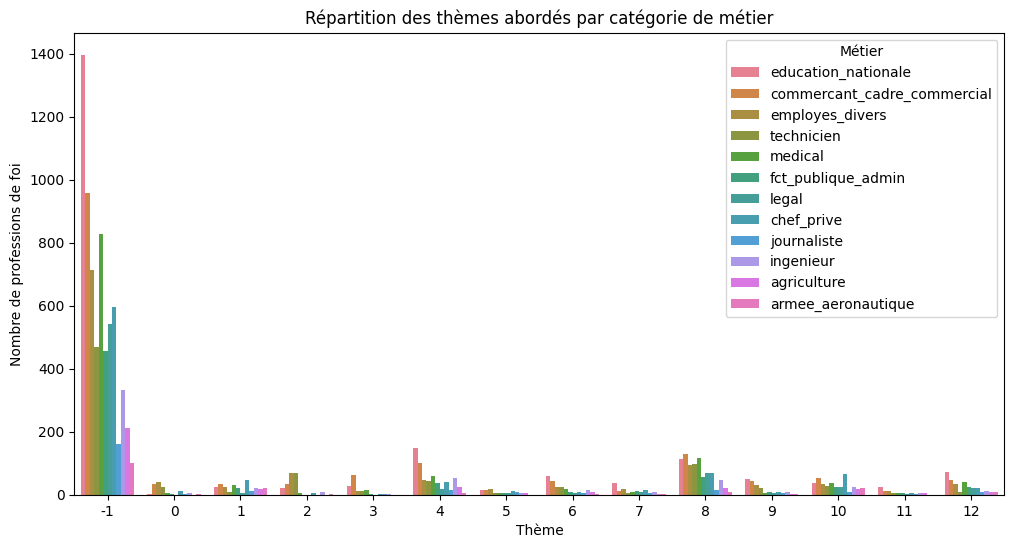

In [59]:
plt.figure(figsize=(12,6))
sns.countplot(x='theme_cluster', hue='profession_category', data=meta_et_texts_metier)
plt.title("Répartition des thèmes abordés par catégorie de métier")
plt.xlabel("Thème")
plt.ylabel("Nombre de professions de foi")
plt.legend(title="Métier")
plt.show()

## Analyses statistiques diverses

In [61]:
contingency_table = pd.crosstab(meta_et_texts_metier['profession_category'], meta_et_texts_metier['theme_cluster'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi2 = 1069.49, p-value = 0.0000
